In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/healthcare-dataset-stroke-data.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB
None
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614     

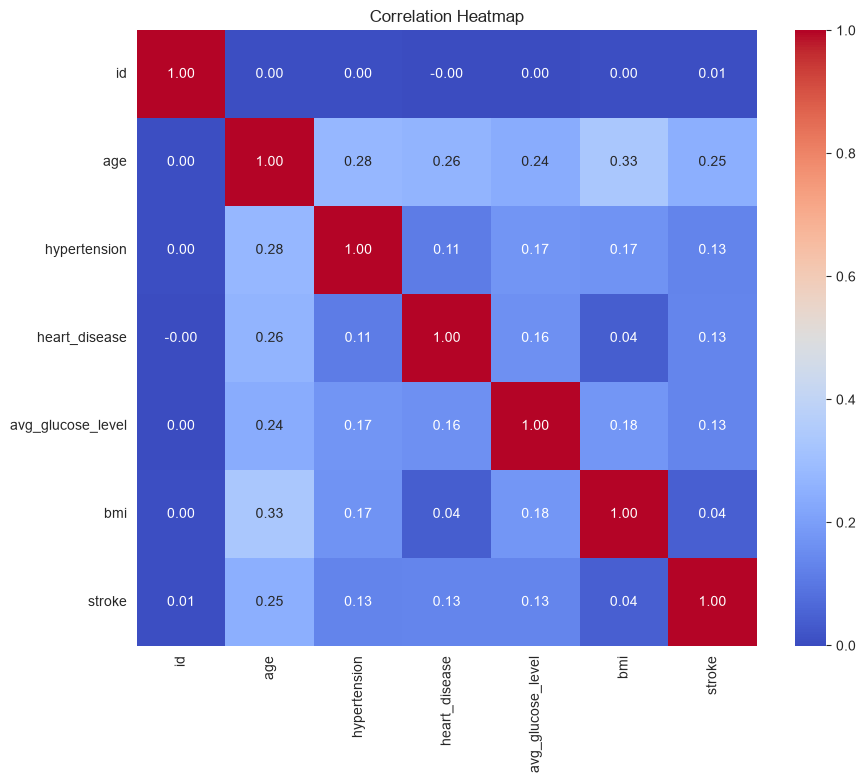

In [3]:
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['stroke'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
df = df.drop('id', axis=1)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
models = {
    "random_forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df



--- random_forest ---
[[950  22]
 [ 44   6]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.21      0.12      0.15        50

    accuracy                           0.94      1022
   macro avg       0.59      0.55      0.56      1022
weighted avg       0.92      0.94      0.93      1022



C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- xgboost ---
[[960  12]
 [ 47   3]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.20      0.06      0.09        50

    accuracy                           0.94      1022
   macro avg       0.58      0.52      0.53      1022
weighted avg       0.92      0.94      0.93      1022


--- logistic_regression ---
[[722 250]
 [ 10  40]]
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



,model,accuracy,precision,recall,f1
2,logistic_regression,0.745597,0.137931,0.80,0.235294
0,random_forest,0.935421,0.214286,0.12,0.153846
1,xgboost,0.942270,0.200000,0.06,0.092308


In [6]:
os.makedirs('../models/stroke', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/stroke/{name}.pkl')

joblib.dump(scaler, '../models/stroke/scaler.pkl')
results_df.to_json('../models/stroke/metrics.json', orient='records')

print("Saved all models, scaler, and metrics.")


Saved all models, scaler, and metrics.


In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()


In [8]:
disease = "stroke"
best_model_name = "random_forest"   # <-- replace with your actual best model from results_df above

model = joblib.load(f'../models/{disease}/{best_model_name}.pkl')
scaler = joblib.load(f'../models/{disease}/scaler.pkl')

df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/healthcare-dataset-stroke-data.csv")
df = df.drop('id', axis=1)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

X = df.drop('stroke', axis=1)
feature_names = X.columns.tolist()
X_scaled = scaler.transform(X)


In [9]:
# Tree-based models (RandomForest, XGBoost, DecisionTree) -> TreeExplainer (fast)
# Others (LogisticRegression, SVM, KNN, Naive Bayes) -> KernelExplainer (slower, needs background sample)

tree_models = ["random_forest", "xgboost", "decision_tree"]

# Sample rows for speed - full dataset explanation isn't needed for the summary plot
X_shap_sample = X_scaled[:300]

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap_sample)
    # For binary classifiers, shap_values may be a list [class0, class1] -> take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_scaled, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_scaled[:100])  # limit rows, KernelExplainer is slow


<Figure size 640x480 with 0 Axes>

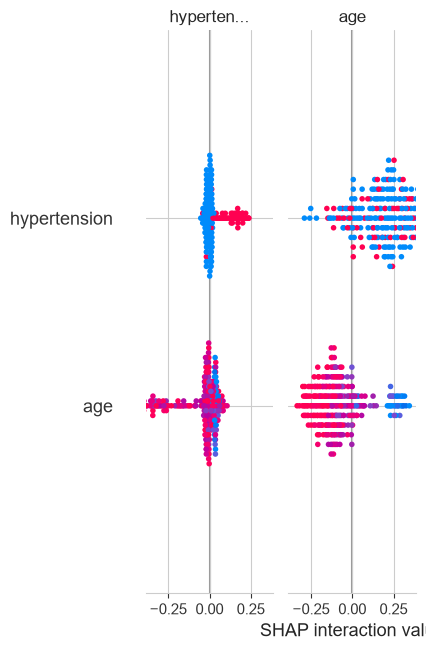

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_bar.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

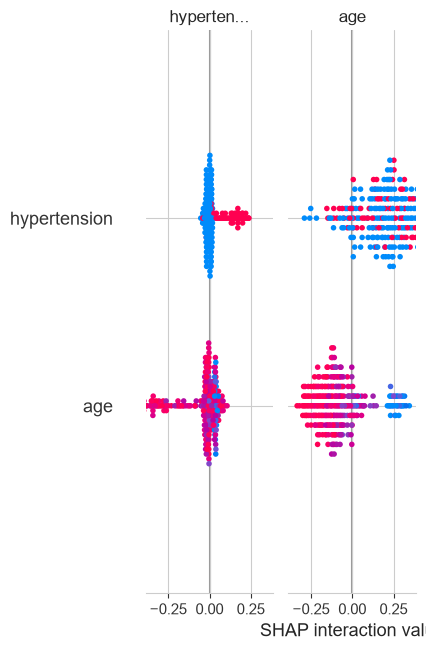

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_beeswarm.png', dpi=150)
plt.show()


In [12]:
def explain_single_prediction(patient_row_scaled, explainer, feature_names, is_tree_model):

    # Get SHAP values
    if is_tree_model:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]  # take first sample

    else:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]

    # Important fix
    sv = np.array(sv).reshape(-1)   # ensures 1D

    # Create dataframe
    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": sv
    })

    impact_df["abs_impact"] = impact_df["shap_value"].abs()

    return impact_df.sort_values("abs_impact", ascending=False)
